# V24: AI Signal Analysis - Threshold vs Signal Quality (TP:FP Ratio)

This notebook focuses on analyzing how the **AI Confidence Threshold** impact the quality of buy signals. 
We visualize the relationship between threshold levels and the **Ratio of True Positives to False Positives (TP:FP)**.

### Key Features:
1. **Threshold Sweep**: Iterating from 0.50 to 0.61.
2. **Signal Quality Chart**: Visualizing the TP:FP ratio curve.
3. **Optimized Strategy**: Applying the best threshold to the Portfolio simulation.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8') # Use seaborn style for that grid look

# --- 1. Load Data ---
file_path = 'dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = '../dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Model Training ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test, y_test = features.loc[test_mask], target.loc[test_mask]

print("Training XGBoost model...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

test_probs = xgb_model.predict_proba(X_test)[:, 1]
print("✓ Done.")

Training XGBoost model...
✓ Done.


Best Threshold based on Visualization: 0.59


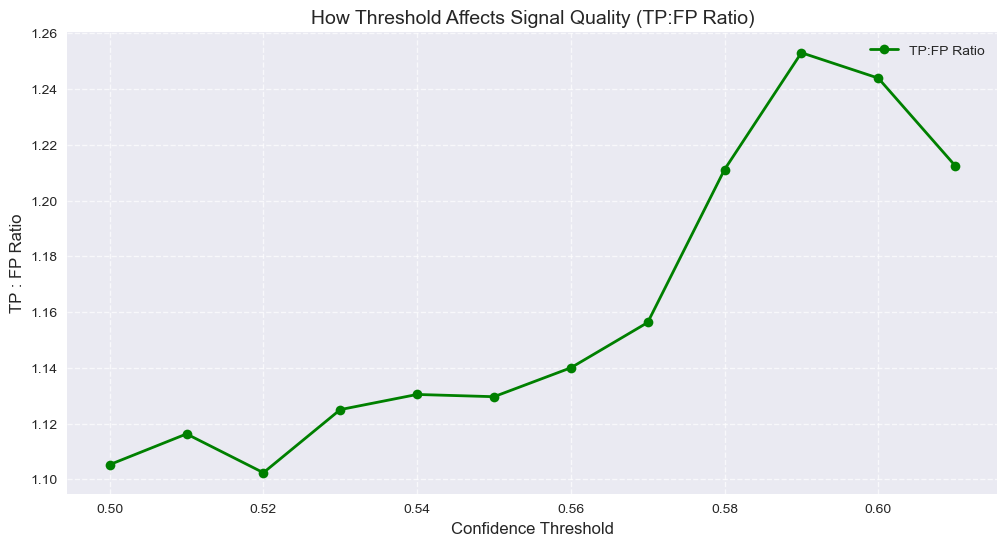

In [3]:
# --- 3. Threshold Analysis & Visualization ---

thresholds = np.arange(0.50, 0.62, 0.01)
ratios = []

for t in thresholds:
    preds = (test_probs >= t).astype(int)
    if np.sum(preds) == 0:
        ratios.append(np.nan)
        continue
        
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    # Ratio of Correct Sinyal to False Sinyal
    ratio = tp / fp if fp > 0 else tp
    ratios.append(ratio)

# Create Visualization
plt.figure(figsize=(12, 6))
plt.plot(thresholds, ratios, color='green', marker='o', linewidth=2, label='TP:FP Ratio')

plt.title("How Threshold Affects Signal Quality (TP:FP Ratio)", fontsize=14)
plt.xlabel("Confidence Threshold", fontsize=12)
plt.ylabel("TP : FP Ratio", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Find max for annotation
max_idx = np.nanargmax(ratios)
opt_threshold = thresholds[max_idx]
print(f"Best Threshold based on Visualization: {opt_threshold:.2f}")

plt.savefig('v24_threshold_signal_quality.png', dpi=300)
plt.show()

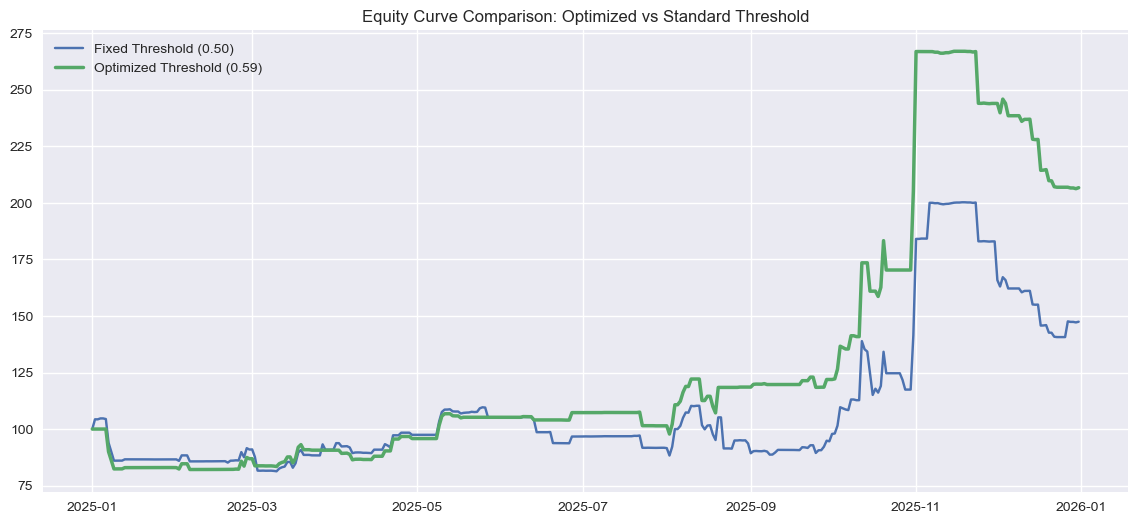

In [4]:
# --- 4. Backtest with Optimized Threshold ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x))

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, use_graph=True):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        if is_risk_off:
            day_ret = 0
        else:
            selected = get_mis_assets(window_rets) if use_graph else window_rets.columns
            w = optimize_markowitz(window_rets[selected])
            day_ret = sum(w[a] * returns.loc[test_dates[i+1], a] for a in w)
        val *= (1 + day_ret)
        history.append(val)
        dates.append(test_dates[i+1])
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

test_dates = X_test.index
prob_series = pd.Series(test_probs, index=test_dates)

res_fixed = run_simulation(test_dates, returns, prob_series, threshold=0.5)
res_opt = run_simulation(test_dates, returns, prob_series, threshold=opt_threshold)

plt.figure(figsize=(14, 6))
plt.plot(res_fixed.index, res_fixed['Portfolio_Value'], label="Fixed Threshold (0.50)")
plt.plot(res_opt.index, res_opt['Portfolio_Value'], label=f"Optimized Threshold ({opt_threshold:.2f})", linewidth=2.5)
plt.title("Equity Curve Comparison: Optimized vs Standard Threshold")
plt.legend()
plt.show()